In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("ev_sales_by_makers_and_cat_15-24.csv")

df.columns = df.columns.str.strip()

print("=================================")
print("FIRST FIVE ROWS")
print("=================================")

display(df.head())

FIRST FIVE ROWS


,Cat,Maker,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,3W,"""VOLVO GROUP INDIA PVT LTD""",0,0,31,12,0,0,0,0,0,0
1,3W,3EV INDUSTRIES PVT LTD,0,0,0,0,0,0,112,390,545,51
2,2W,3GB TECHNOLOGY PVT LTD,0,0,0,1,0,0,0,0,0,0
3,3W,3GB TECHNOLOGY PVT LTD,0,1,1,0,0,0,0,0,0,0
4,3W,3S INDUSTRIES PRIVATE LIMITED,0,0,0,0,48,66,43,68,266,578


In [4]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Dataset Shape:
(1386, 12)

Column Names:
Index(['Cat', 'Maker', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       '2022', '2023', '2024'],
      dtype='str')

Data Types:
Cat        str
Maker      str
2015     int64
2016     int64
2017     int64
2018     int64
2019     int64
2020     int64
2021     int64
2022     int64
2023     int64
2024     int64
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Cat     1386 non-null   str  
 1   Maker   1386 non-null   str  
 2   2015    1386 non-null   int64
 3   2016    1386 non-null   int64
 4   2017    1386 non-null   int64
 5   2018    1386 non-null   int64
 6   2019    1386 non-null   int64
 7   2020    1386 non-null   int64
 8   2021    1386 non-null   int64
 9   2022    1386 non-null   int64
 10  2023    1386 non-null   int64
 11  2024    1386 non-null   int64
dtypes: int64

In [5]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numerical values with mean
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
Cat      0
Maker    0
2015     0
2016     0
2017     0
2018     0
2019     0
2020     0
2021     0
2022     0
2023     0
2024     0
dtype: int64


In [6]:
print("\nDescriptive Statistics")
display(df.describe())



Descriptive Statistics


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000
mean,5.593074,35.533189,62.784271,93.624098,119.614719,89.300144,237.268398,736.315296,1103.343434,706.308081
std,62.430741,400.757230,496.932817,511.486338,692.529043,504.744348,1793.878376,5917.016908,9631.219039,7022.251339
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000
75%,0.000000,0.000000,3.000000,6.000000,10.000000,7.000000,13.000000,39.000000,96.000000,79.000000
max,1708.000000,13401.000000,15094.000000,10816.000000,13213.000000,9543.000000,46260.000000,109398.000000,267355.000000,211273.000000


In [7]:
year_cols = ['2015','2016','2017','2018','2019','2020','2021','2022','2023','2024']

df['Total_Sales'] = df[year_cols].sum(axis=1)

print("\nTop EV Makers by Total Sales")

display(df[['Maker','Cat','Total_Sales']]
        .sort_values(by='Total_Sales',ascending=False)
        .head(10))


Top EV Makers by Total Sales


,Maker,Cat,Total_Sales
867,OLA ELECTRIC TECHNOLOGIES PVT LTD,2W,588266
1230,TVS MOTOR COMPANY LTD,2W,318227
118,ATHER ENERGY PVT LTD,2W,236387
472,HERO ELECTRIC VEHICLES PVT. LTD,2W,201647
864,OKINAWA AUTOTECH PVT LTD,2W,196176
148,BAJAJ AUTO LTD,2W,177128
1357,YC ELECTRIC VEHICLE,3W,152944
76,AMPERE VEHICLES PRIVATE LIMITED,2W,141805
1020,SAERA ELECTRIC AUTO PVT LTD,3W,87475
1203,TATA PASSENGER ELECTRIC MOBILITY LTD,LMV,74410


In [8]:
print("\nAverage EV Sales by Category")

category_avg = df.groupby('Cat')['Total_Sales'].mean()

print(category_avg)


Average EV Sales by Category
Cat
2W     8733.517241
3W     2233.560046
LMV     852.842975
MMV      47.294118
Name: Total_Sales, dtype: float64


In [9]:
print("\nCorrelation Matrix")

correlation = df[year_cols].corr()

display(correlation)


Correlation Matrix


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
2015,1.000000,0.876021,0.641184,0.112157,0.039752,0.039526,0.036334,0.034827,0.051595,0.050281
2016,0.876021,1.000000,0.860318,0.225158,0.130046,0.117789,0.064326,0.041266,0.034937,0.024118
2017,0.641184,0.860318,1.000000,0.503320,0.371066,0.342091,0.179371,0.110001,0.084217,0.059245
2018,0.112157,0.225158,0.503320,1.000000,0.956588,0.855403,0.688664,0.509604,0.214769,0.105268
2019,0.039752,0.130046,0.371066,0.956588,1.000000,0.932897,0.801372,0.605297,0.252106,0.118328
2020,0.039526,0.117789,0.342091,0.855403,0.932897,1.000000,0.837656,0.650989,0.304750,0.159439
2021,0.036334,0.064326,0.179371,0.688664,0.801372,0.837656,1.000000,0.781130,0.313418,0.165335
2022,0.034827,0.041266,0.110001,0.509604,0.605297,0.650989,0.781130,1.000000,0.740534,0.608604
2023,0.051595,0.034937,0.084217,0.214769,0.252106,0.304750,0.313418,0.740534,1.000000,0.959600
2024,0.050281,0.024118,0.059245,0.105268,0.118328,0.159439,0.165335,0.608604,0.959600,1.000000


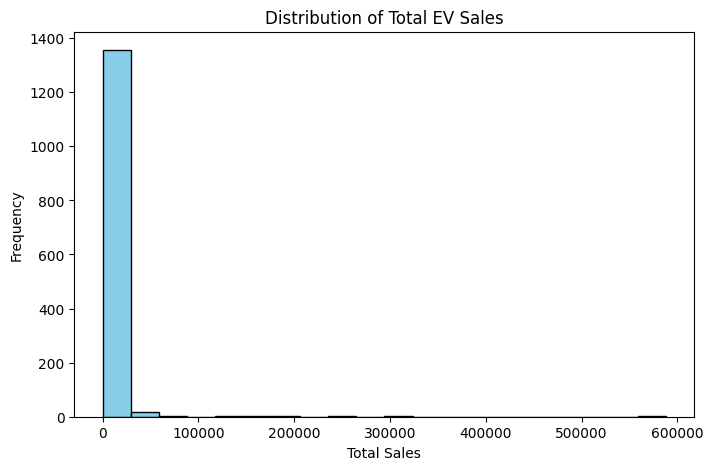

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df['Total_Sales'],
         bins=20,
         color='skyblue',
         edgecolor='black')

plt.title("Distribution of Total EV Sales")

plt.xlabel("Total Sales")

plt.ylabel("Frequency")

plt.show()

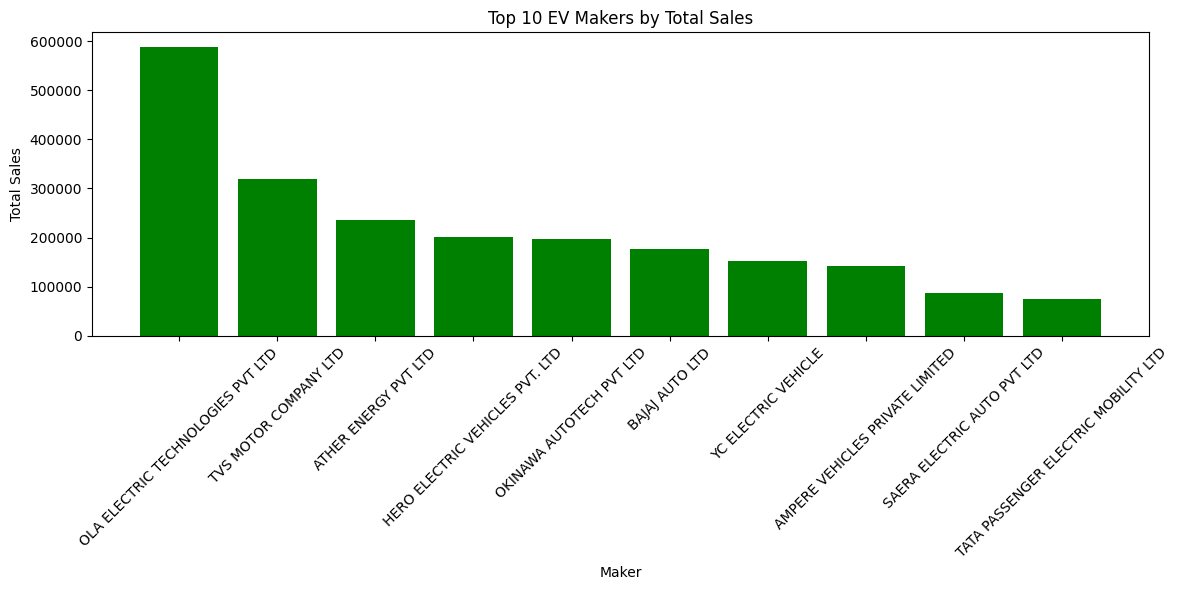

In [11]:
top10 = df.sort_values(by='Total_Sales',
                       ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.bar(top10['Maker'],
        top10['Total_Sales'],
        color='green')

plt.xticks(rotation=45)

plt.title("Top 10 EV Makers by Total Sales")

plt.xlabel("Maker")

plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

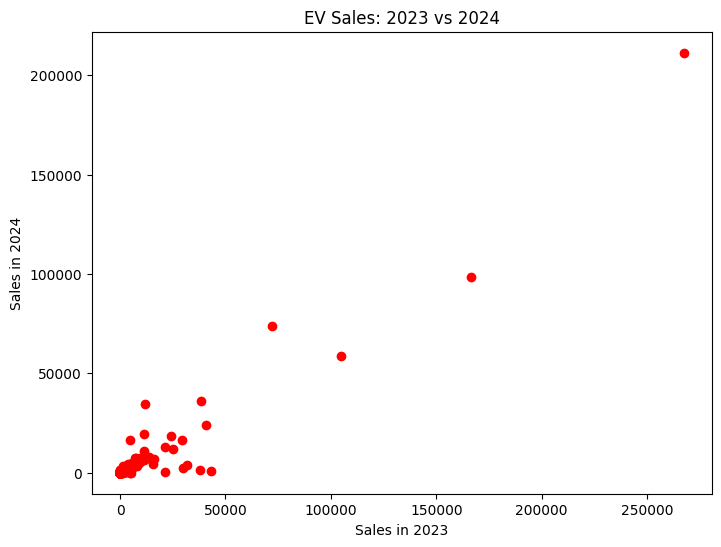

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(df['2023'],
            df['2024'],
            color='red')

plt.title("EV Sales: 2023 vs 2024")

plt.xlabel("Sales in 2023")

plt.ylabel("Sales in 2024")

plt.show()

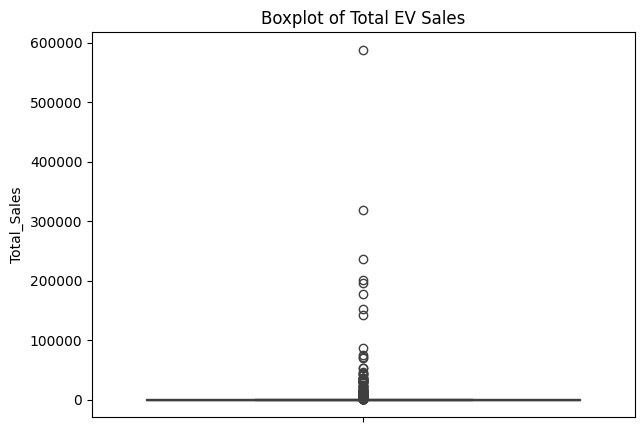

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(y=df['Total_Sales'])

plt.title("Boxplot of Total EV Sales")

plt.show()

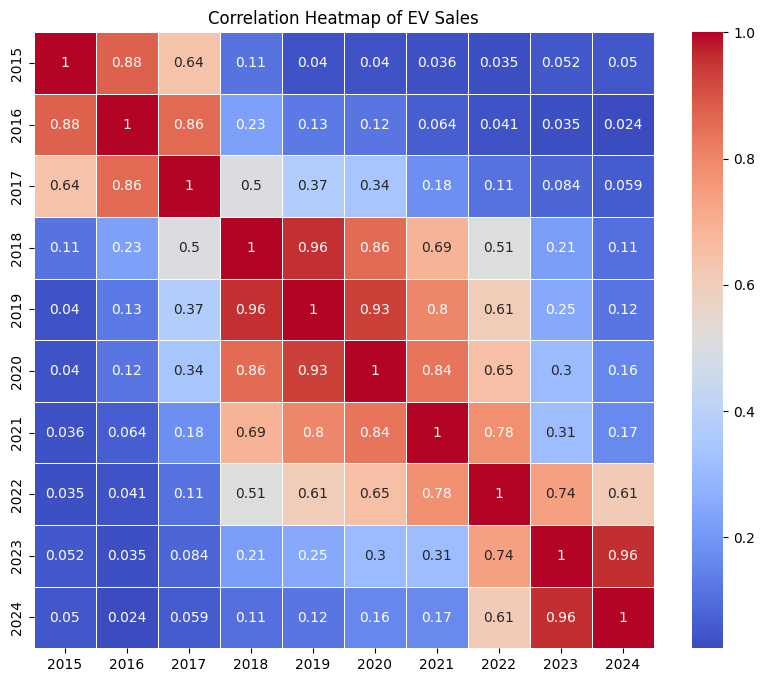

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap of EV Sales")

plt.show()

In [15]:
print("\nTop EV Categories")

category_total = df.groupby('Cat')['Total_Sales'].sum()

print(category_total.sort_values(ascending=False))


Top EV Categories
Cat
2W     2279448
3W     1934263
LMV     206388
MMV        804
Name: Total_Sales, dtype: int64


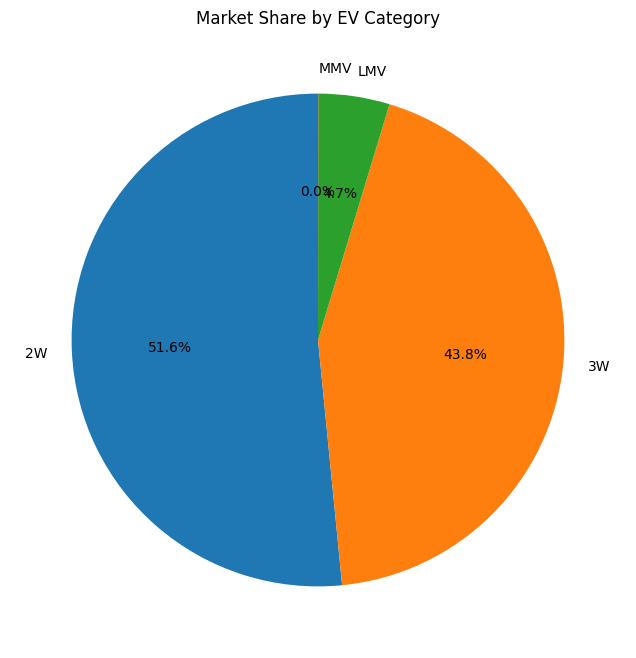

In [16]:
plt.figure(figsize=(8,8))

category_total.plot(kind='pie',
                    autopct='%1.1f%%',
                    startangle=90)

plt.ylabel("")

plt.title("Market Share by EV Category")

plt.show()

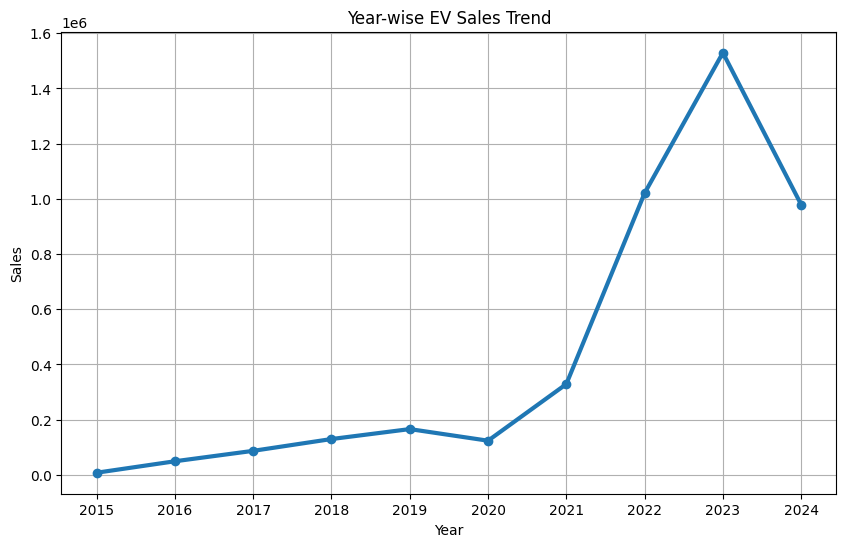

In [17]:
year_sales = df[year_cols].sum()

plt.figure(figsize=(10,6))

plt.plot(year_cols,
         year_sales,
         marker='o',
         linewidth=3)

plt.title("Year-wise EV Sales Trend")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [18]:
print("\n========== PROJECT SUMMARY ==========")

print("1. Dataset cleaned successfully.")

print("2. Missing values handled.")

print("3. Duplicate rows removed.")

print("4. Total EV Sales calculated.")

print("5. Category-wise sales analyzed.")

print("6. Top EV makers identified.")

print("7. Visualizations generated successfully.")

print("\nEDA Completed Successfully!")


========== PROJECT SUMMARY ==========
1. Dataset cleaned successfully.
2. Missing values handled.
3. Duplicate rows removed.
4. Total EV Sales calculated.
5. Category-wise sales analyzed.
6. Top EV makers identified.
7. Visualizations generated successfully.

EDA Completed Successfully!
